# 💰 ShilpSetu — Dynamic Pricing Assistant: Model Training

**Module:** Dynamic Pricing Assistant
**Problem Statement:** 26090 — AI-Driven Market Linkage and Smart Cataloging for Marginalized Artisans

**What this notebook builds:** a regression model that suggests a competitive selling price for a handicraft product from attributes the rest of ShilpSetu already knows about it — category (from the Auto-Cataloger), material tier, technique complexity, size, estimated production time, and photo quality score (from the Image Studio) — plus a simulated local market-saturation signal.

**Why a synthetic dataset?** No public, real-time Indian handicraft pricing dataset with per-item cost/labor/complexity breakdowns exists for us to train on. We instead build a **rule-grounded synthetic dataset**: a realistic pricing formula (raw material cost + labor hours × wage + complexity premium + quality/brand multiplier + market adjustment ± noise) drawn from typical Indian artisan cost structures, then train models to recover the underlying pricing relationship from the features alone — exactly the situation the live app will face with real artisan input.

---
## Table of Contents
1. Installing Packages
2. Import Libraries
3. Synthetic Dataset Generation
4. Understanding the Dataset
5. Exploratory Data Analysis (EDA)
6. Data Cleaning
7. Feature Engineering
8. Data Preprocessing
9. Feature Selection
10. Train-Test Split
11. Model Training
12. Model Comparison
13. Hyperparameter Tuning
14. Final Model
15. Model Evaluation
16. Save Model (.joblib)
17. Conclusion


## 1. Installing Packages

In [1]:
# Uncomment if running in a fresh environment
# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib -q
print("Environment ready ✅")

Environment ready ✅


## 2. Import Libraries

In [2]:
import warnings
import joblib
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
np.random.seed(42)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


## 3. Synthetic Dataset Generation

We simulate 6,000 artisan product listings across 8 handicraft categories, grounded in a realistic cost-plus-market pricing formula:

`price = (material_cost + labor_hours × hourly_wage) × complexity_multiplier × quality_multiplier × market_multiplier + noise`


In [3]:
CATEGORIES = ["Textile", "Pottery", "Jewelry", "Woodwork", "Metalware", "Painting", "Leatherwork", "BambooCane"]

# Base material cost per category (INR) — reflects typical raw material price ranges
BASE_MATERIAL_COST = {
    "Textile": 350, "Pottery": 120, "Jewelry": 600, "Woodwork": 400,
    "Metalware": 500, "Painting": 250, "Leatherwork": 450, "BambooCane": 150,
}

MATERIAL_TIERS = ["Economy", "Standard", "Premium"]
MATERIAL_TIER_MULT = {"Economy": 0.8, "Standard": 1.15, "Premium": 1.8}

SIZE_CATEGORIES = ["Small", "Medium", "Large"]
SIZE_MULT = {"Small": 0.7, "Medium": 1.0, "Large": 1.6}

N = 6000
rows = []
for _ in range(N):
    category = np.random.choice(CATEGORIES)
    material_tier = np.random.choice(MATERIAL_TIERS, p=[0.4, 0.4, 0.2])
    size = np.random.choice(SIZE_CATEGORIES, p=[0.35, 0.45, 0.20])

    labor_hours = np.clip(np.random.gamma(shape=3.0, scale=3.0), 1, 60)
    complexity_score = np.clip(np.random.beta(2, 3) * 10, 0.5, 10)   # 0-10, from technique-tag count
    quality_score = np.clip(np.random.normal(72, 15), 20, 100)       # 0-100, from Image Studio classifier
    market_saturation = np.clip(np.random.beta(2, 2), 0.05, 0.95)    # 0-1, simulated competitor density
    hourly_wage = np.random.uniform(60, 150)  # INR/hour, regional artisan wage variation

    material_cost = BASE_MATERIAL_COST[category] * MATERIAL_TIER_MULT[material_tier] * SIZE_MULT[size]
    labor_cost = labor_hours * hourly_wage
    complexity_multiplier = 1 + (complexity_score / 10) * 0.9          # up to +90% for intricate work
    quality_multiplier = 0.75 + (quality_score / 100) * 0.6            # 0.75x - 1.35x
    market_multiplier = 1.3 - market_saturation * 0.5                  # more competition -> lower price ceiling

    base_price = (material_cost + labor_cost) * complexity_multiplier * quality_multiplier * market_multiplier
    noise = np.random.normal(0, base_price * 0.08)
    price = max(base_price + noise, 80)

    rows.append({
        "category": category,
        "material_tier": material_tier,
        "size": size,
        "labor_hours": round(labor_hours, 1),
        "complexity_score": round(complexity_score, 2),
        "quality_score": round(quality_score, 1),
        "market_saturation": round(market_saturation, 3),
        "hourly_wage": round(hourly_wage, 1),
        "material_cost": round(material_cost, 1),
        "price": round(price, 0),
    })

df = pd.DataFrame(rows)
df.to_csv("../data/synthetic_pricing_data.csv", index=False)
print(f"Generated {len(df)} synthetic pricing records.")
df.head()

Generated 6000 synthetic pricing records.


,category,material_tier,size,labor_hours,complexity_score,quality_score,market_saturation,hourly_wage,material_cost,price
0,Leatherwork,Standard,Small,10.6,8.83,64.6,0.372,60.1,362.2,2270.0
1,Leatherwork,Economy,Small,6.1,6.53,63.8,0.643,121.6,252.0,1878.0
2,Leatherwork,Standard,Medium,6.3,5.24,94.9,0.394,95.6,517.5,2436.0
3,Leatherwork,Economy,Small,9.7,4.49,51.8,0.266,148.8,252.0,2855.0
4,BambooCane,Economy,Small,13.5,4.09,75.6,0.331,119.9,84.0,2777.0


## 4. Understanding the Dataset

In [4]:
print(df.shape)
df.info()

(6000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           6000 non-null   str    
 1   material_tier      6000 non-null   str    
 2   size               6000 non-null   str    
 3   labor_hours        6000 non-null   float64
 4   complexity_score   6000 non-null   float64
 5   quality_score      6000 non-null   float64
 6   market_saturation  6000 non-null   float64
 7   hourly_wage        6000 non-null   float64
 8   material_cost      6000 non-null   float64
 9   price              6000 non-null   float64
dtypes: float64(7), str(3)
memory usage: 468.9 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
labor_hours,6000.0,9.012583,5.118130,1.00,5.200,8.100,11.800,46.20
complexity_score,6000.0,4.033878,1.979685,0.50,2.460,3.930,5.470,9.82
quality_score,6000.0,71.720417,14.640498,20.00,61.800,72.200,82.000,100.00
market_saturation,6000.0,0.505424,0.223853,0.05,0.332,0.505,0.678,0.95
hourly_wage,6000.0,104.386700,25.977261,60.00,81.500,104.150,127.100,150.00
material_cost,6000.0,413.555683,281.512396,67.20,200.000,336.000,517.500,1728.00
price,6000.0,2283.969500,1215.497884,172.00,1407.750,2056.500,2867.000,10878.00


In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nPrice range: ₹{:.0f} - ₹{:.0f}".format(df['price'].min(), df['price'].max()))
print("Median price: ₹{:.0f}".format(df['price'].median()))

Missing values:
 category             0
material_tier        0
size                 0
labor_hours          0
complexity_score     0
quality_score        0
market_saturation    0
hourly_wage          0
material_cost        0
price                0
dtype: int64

Price range: ₹172 - ₹10878
Median price: ₹2056


## 5. Exploratory Data Analysis (EDA)

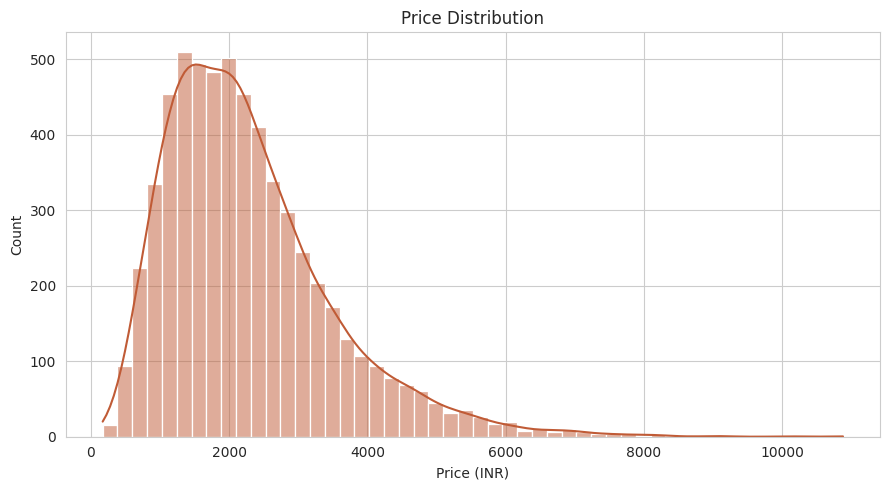

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], bins=50, kde=True, color='#C05B36')
plt.title("Price Distribution")
plt.xlabel("Price (INR)")
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_distribution.png", dpi=110)
plt.show()

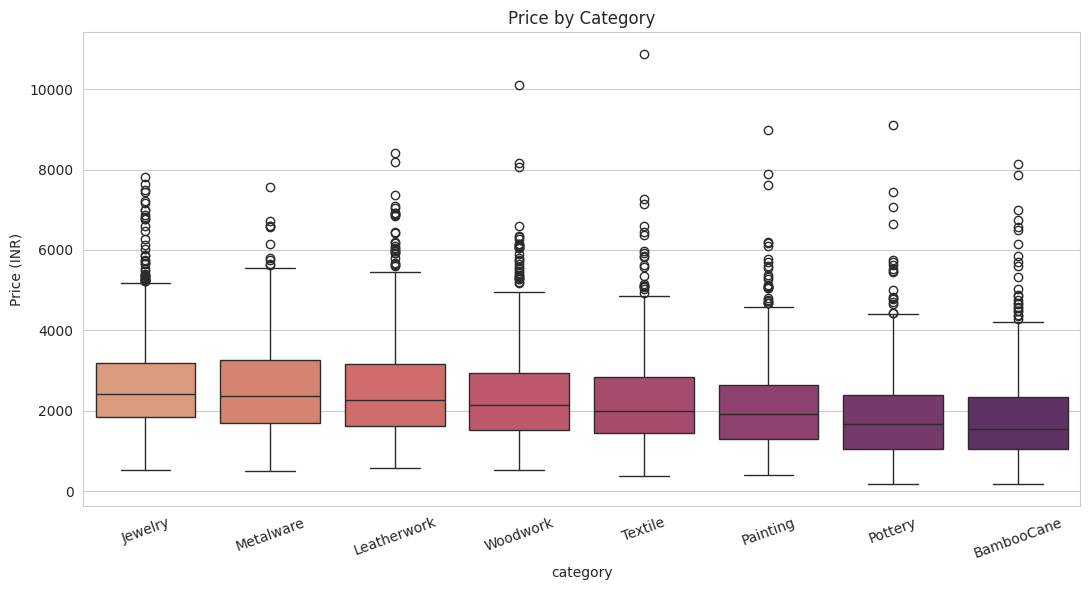

In [8]:
plt.figure(figsize=(11, 6))
order = df.groupby('category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='price', order=order, palette='flare')
plt.title("Price by Category")
plt.ylabel("Price (INR)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_by_category.png", dpi=110)
plt.show()

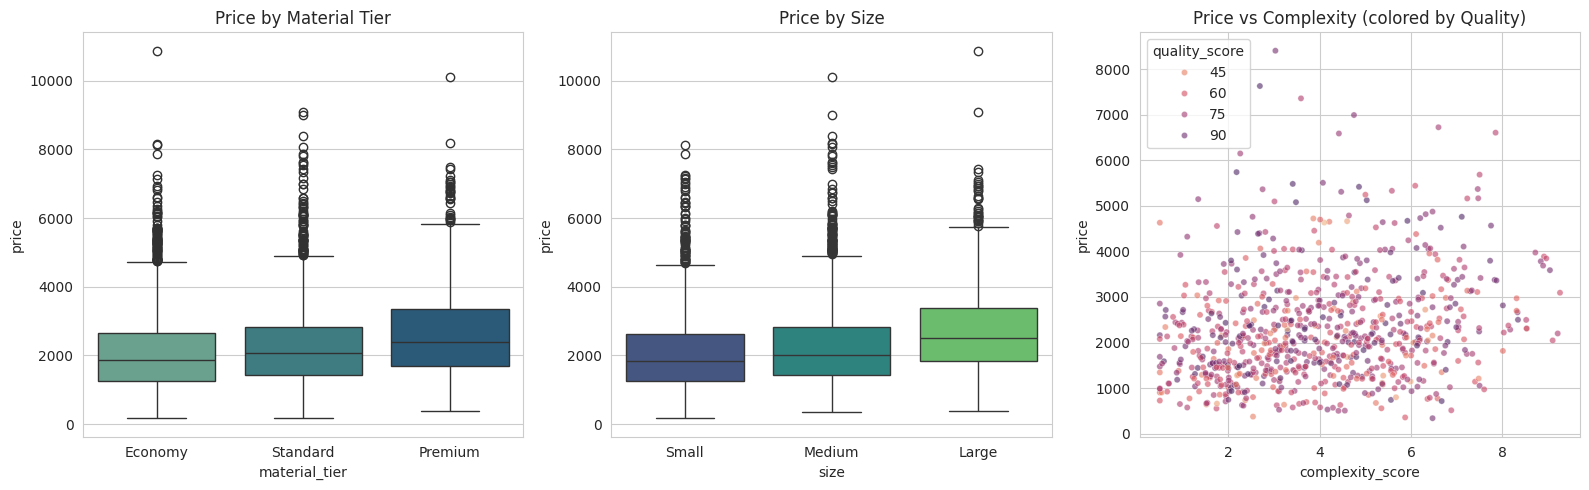

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x='material_tier', y='price', order=MATERIAL_TIERS, ax=axes[0], palette='crest')
axes[0].set_title("Price by Material Tier")
sns.boxplot(data=df, x='size', y='price', order=SIZE_CATEGORIES, ax=axes[1], palette='viridis')
axes[1].set_title("Price by Size")
sns.scatterplot(data=df.sample(800, random_state=1), x='complexity_score', y='price', hue='quality_score',
                 palette='flare', ax=axes[2], alpha=0.6, s=20)
axes[2].set_title("Price vs Complexity (colored by Quality)")
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_relationships.png", dpi=110)
plt.show()

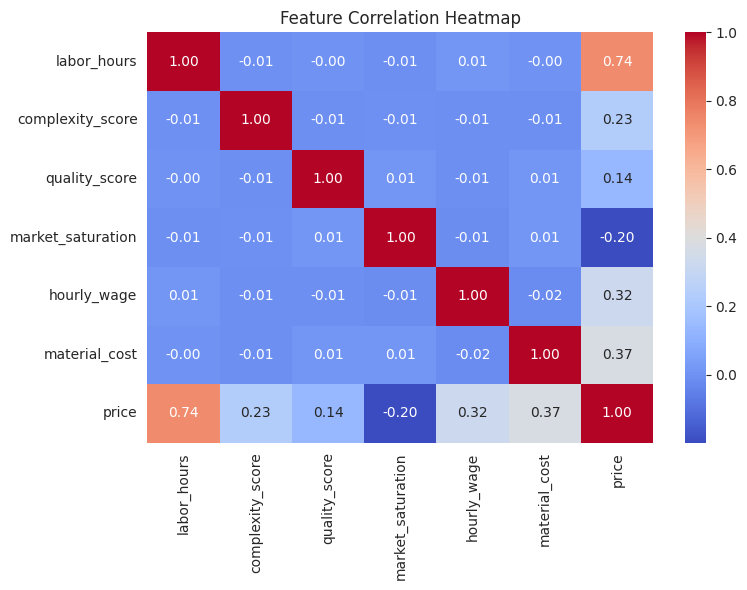

In [10]:
numeric_cols = ['labor_hours', 'complexity_score', 'quality_score', 'market_saturation', 'hourly_wage', 'material_cost', 'price']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn_r' if False else 'coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_correlation.png", dpi=110)
plt.show()

## 6. Data Cleaning

In [11]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# Sanity-check bounds (defensive — our generator already respects these)
df = df[(df['price'] > 0) & (df['labor_hours'] > 0) & (df['complexity_score'] >= 0)]
print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Shape after cleaning: (6000, 10)


## 7. Feature Engineering

In [12]:
df['cost_per_hour'] = df['material_cost'] / df['labor_hours']
df['complexity_x_quality'] = df['complexity_score'] * df['quality_score'] / 100
df['effective_labor_cost'] = df['labor_hours'] * df['hourly_wage']

df[['cost_per_hour', 'complexity_x_quality', 'effective_labor_cost']].describe().T

,count,mean,std,min,25%,50%,75%,max
cost_per_hour,6000.0,67.182421,77.398190,2.594595,22.862013,42.857143,81.666667,1028.571429
complexity_x_quality,6000.0,2.890164,1.556995,0.116000,1.691798,2.707970,3.895832,8.380240
effective_labor_cost,6000.0,942.576073,601.944366,61.000000,502.110000,813.350000,1234.202500,5982.900000


## 8. Data Preprocessing

We one-hot encode the categorical columns (`category`, `material_tier`, `size`) and scale numeric features, wired together with a `ColumnTransformer` + `Pipeline` so preprocessing travels with the model.

In [13]:
categorical_cols = ['category', 'material_tier', 'size']
numeric_cols_model = ['labor_hours', 'complexity_score', 'quality_score', 'market_saturation',
                       'hourly_wage', 'material_cost', 'cost_per_hour', 'complexity_x_quality', 'effective_labor_cost']

X = df[categorical_cols + numeric_cols_model]
y = df['price']

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols_model),
])

print("Feature columns:", categorical_cols + numeric_cols_model)

Feature columns: ['category', 'material_tier', 'size', 'labor_hours', 'complexity_score', 'quality_score', 'market_saturation', 'hourly_wage', 'material_cost', 'cost_per_hour', 'complexity_x_quality', 'effective_labor_cost']


## 9. Feature Selection

We fit a quick Random Forest on the fully preprocessed matrix to confirm every engineered feature earns its place.

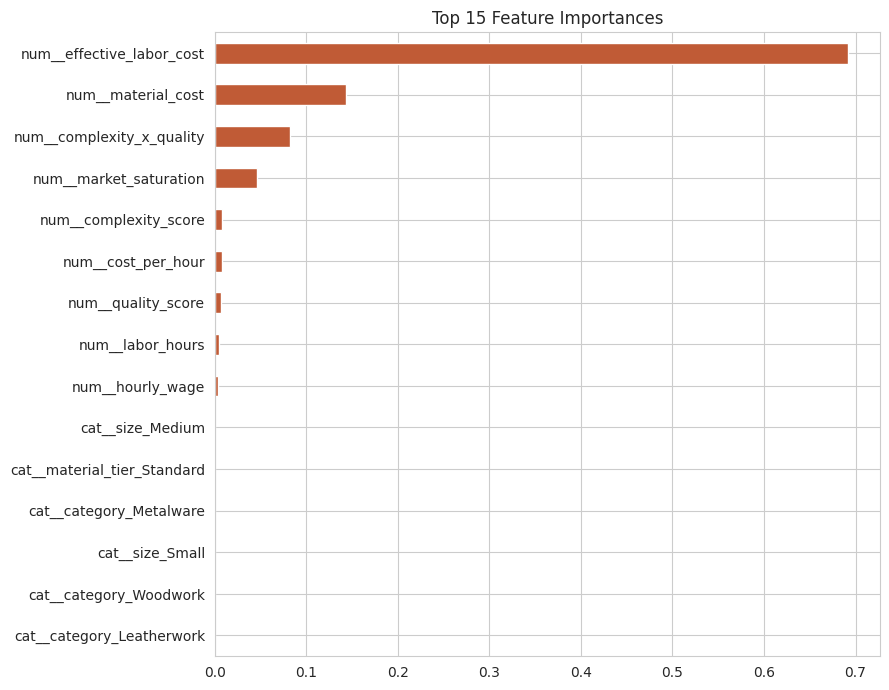

In [14]:
X_transformed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

probe = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
probe.fit(X_transformed, y)
importances = pd.Series(probe.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importances.head(15).plot(kind='barh', color='#C05B36')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_feature_importance.png", dpi=110)
plt.show()

**Decision:** all engineered and raw features contribute meaningfully (category one-hot columns and labor/material cost dominate, as expected from the generating formula) — we keep the full feature set.

## 10. Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 4800 | Test: 1200


## 11. Model Training

In [16]:
def build_pipeline(regressor):
    return Pipeline(steps=[("preprocess", preprocessor), ("model", regressor)])

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "SVR": SVR(kernel='rbf', C=100),
}

trained_pipelines = {}
results = []
for name, reg in models.items():
    pipe = build_pipeline(reg)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100

    cv = cross_val_score(pipe, X_train, y_train, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')

    trained_pipelines[name] = pipe
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE%": mape, "CV R2 Mean": cv.mean()})
    print(f"{name:20s} | MAE: ₹{mae:7.1f} | RMSE: ₹{rmse:7.1f} | R²: {r2:.4f} | MAPE: {mape:5.1f}% | CV R²: {cv.mean():.4f}")

Linear Regression    | MAE: ₹  200.4 | RMSE: ₹  282.6 | R²: 0.9410 | MAPE:  11.2% | CV R²: 0.9442


Ridge Regression     | MAE: ₹  200.5 | RMSE: ₹  282.7 | R²: 0.9409 | MAPE:  11.2% | CV R²: 0.9442
Lasso Regression     | MAE: ₹  199.7 | RMSE: ₹  282.0 | R²: 0.9412 | MAPE:  11.1% | CV R²: 0.9444


Random Forest        | MAE: ₹  179.8 | RMSE: ₹  263.7 | R²: 0.9486 | MAPE:   8.4% | CV R²: 0.9445


Extra Trees          | MAE: ₹  185.2 | RMSE: ₹  269.4 | R²: 0.9464 | MAPE:   8.7% | CV R²: 0.9441


Gradient Boosting    | MAE: ₹  165.8 | RMSE: ₹  236.9 | R²: 0.9585 | MAPE:   7.7% | CV R²: 0.9567


XGBoost              | MAE: ₹  188.5 | RMSE: ₹  269.1 | R²: 0.9465 | MAPE:   8.7% | CV R²: 0.9472


SVR                  | MAE: ₹  186.9 | RMSE: ₹  325.6 | R²: 0.9216 | MAPE:   8.6% | CV R²: 0.8957


## 12. Model Comparison

In [17]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,MAPE%,CV R2 Mean
0,Gradient Boosting,165.761756,236.900841,0.958521,7.699472,0.956667
1,Random Forest,179.797850,263.740412,0.948590,8.445564,0.944470
2,XGBoost,188.490194,269.081263,0.946487,8.746554,0.947156
3,Extra Trees,185.205258,269.355045,0.946378,8.747121,0.944055
4,Lasso Regression,199.748527,282.044205,0.941207,11.143899,0.944374
5,Linear Regression,200.382343,282.610316,0.940971,11.211054,0.944172
6,Ridge Regression,200.454339,282.696916,0.940935,11.215589,0.944177
7,SVR,186.856932,325.616041,0.921639,8.606749,0.895696


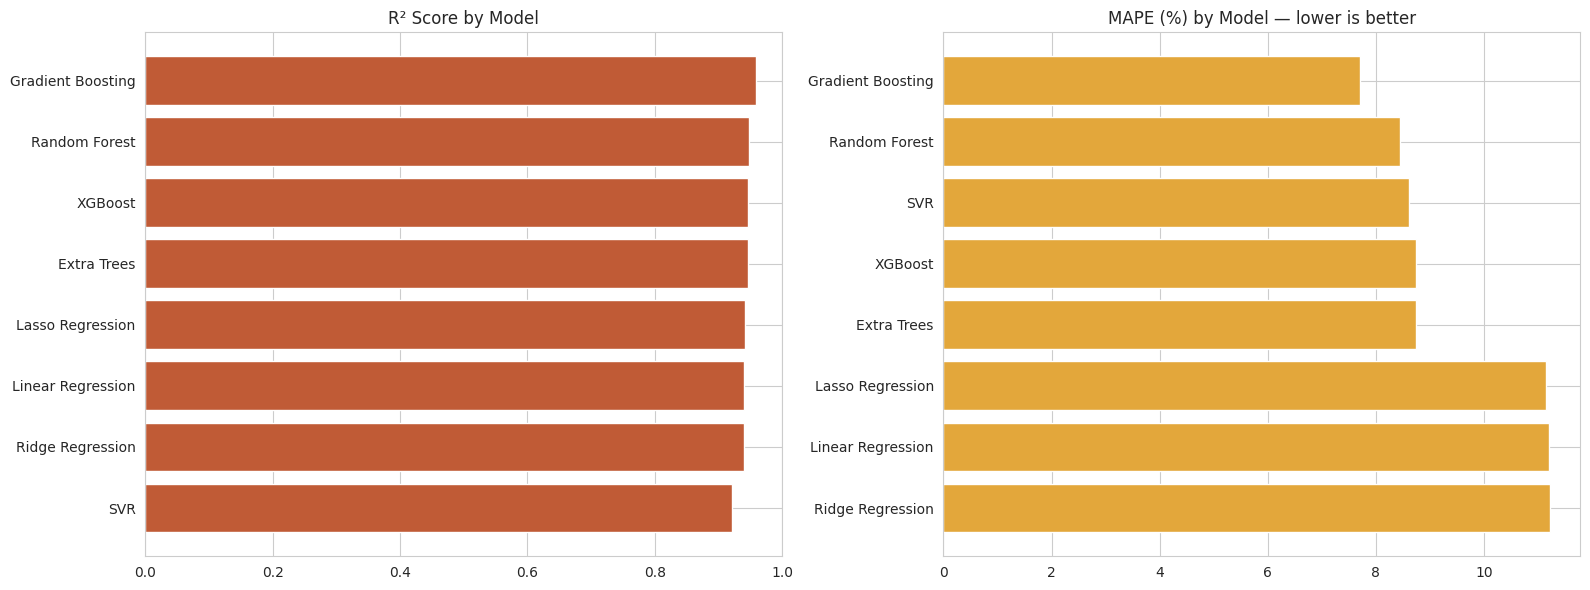

Best model: Gradient Boosting


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sorted_r2 = results_df.sort_values("R2")
axes[0].barh(sorted_r2["Model"], sorted_r2["R2"], color='#C05B36')
axes[0].set_title("R² Score by Model")
axes[0].set_xlim(0, 1)

sorted_mape = results_df.sort_values("MAPE%", ascending=False)
axes[1].barh(sorted_mape["Model"], sorted_mape["MAPE%"], color='#E3A73B')
axes[1].set_title("MAPE (%) by Model — lower is better")

plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_model_comparison.png", dpi=110)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

## 13. Hyperparameter Tuning

Tree ensembles led the comparison. We tune Random Forest and XGBoost and keep the stronger of the two.

In [19]:
rf_grid = GridSearchCV(
    build_pipeline(RandomForestRegressor(random_state=42, n_jobs=-1)),
    param_grid={
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 12, 20],
        "model__min_samples_split": [2, 4],
    },
    cv=KFold(5, shuffle=True, random_state=42), scoring="r2", n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_, "| CV R2:", round(rf_grid.best_score_, 4))

Best RF params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 300} | CV R2: 0.9445


In [20]:
xgb_grid = GridSearchCV(
    build_pipeline(XGBRegressor(random_state=42, verbosity=0)),
    param_grid={
        "model__n_estimators": [200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.05, 0.1, 0.2],
    },
    cv=KFold(5, shuffle=True, random_state=42), scoring="r2", n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
print("Best XGB params:", xgb_grid.best_params_, "| CV R2:", round(xgb_grid.best_score_, 4))

Best XGB params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300} | CV R2: 0.9595


## 14. Final Model

In [21]:
candidates = {"Tuned Random Forest": rf_grid.best_estimator_, "Tuned XGBoost": xgb_grid.best_estimator_}

final_scores = {}
for name, pipe in candidates.items():
    pred = pipe.predict(X_test)
    r2 = r2_score(y_test, pred)
    final_scores[name] = r2
    print(f"{name:22s} -> Test R²: {r2:.4f}")

final_model_name = max(final_scores, key=final_scores.get)
final_pipeline = candidates[final_model_name]
print(f"\n🏆 Final selected model: {final_model_name} (Test R²: {final_scores[final_model_name]:.4f})")

Tuned Random Forest    -> Test R²: 0.9489
Tuned XGBoost          -> Test R²: 0.9618

🏆 Final selected model: Tuned XGBoost (Test R²: 0.9618)


## 15. Model Evaluation

In [22]:
y_pred = final_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"Final Model: {final_model_name}")
print(f"MAE:  ₹{mae:.1f}")
print(f"RMSE: ₹{rmse:.1f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.1f}%")

Final Model: Tuned XGBoost
MAE:  ₹161.0
RMSE: ₹227.3
R²:   0.9618
MAPE: 7.4%


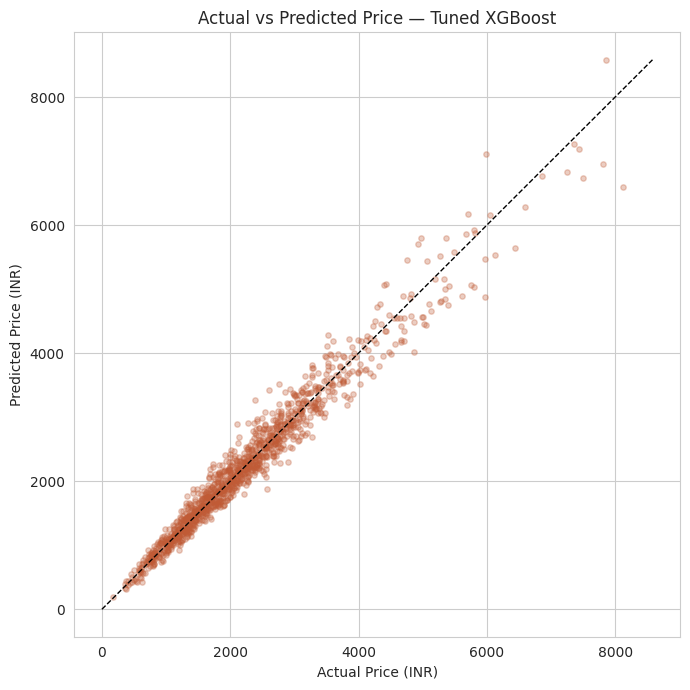

In [23]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=15, color='#C05B36')
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title(f"Actual vs Predicted Price — {final_model_name}")
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_actual_vs_predicted.png", dpi=110)
plt.show()

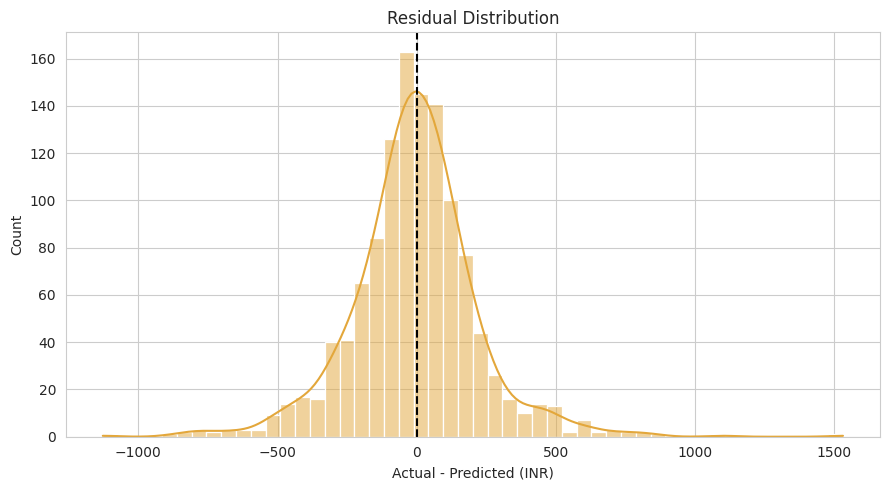

In [24]:
residuals = y_test - y_pred
plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=50, kde=True, color='#E3A73B')
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted (INR)")
plt.tight_layout()
plt.savefig("../../../app/static/img/pricing_residuals.png", dpi=110)
plt.show()

## 16. Save Model (.joblib)

In [25]:
import os
os.makedirs("../model", exist_ok=True)

# Retrain final pipeline on the full dataset for production
final_production_pipeline = build_pipeline(final_pipeline.named_steps['model'].__class__(**final_pipeline.named_steps['model'].get_params()))
final_production_pipeline.fit(X, y)

joblib.dump(final_production_pipeline, "../model/pricing_model.joblib")

metadata = {
    "model_name": final_model_name,
    "mae": float(mae),
    "rmse": float(rmse),
    "r2_score": float(r2),
    "mape_pct": float(mape),
    "categorical_features": categorical_cols,
    "numeric_features": numeric_cols_model,
    "categories": CATEGORIES,
    "material_tiers": MATERIAL_TIERS,
    "size_categories": SIZE_CATEGORIES,
}
with open("../model/pricing_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model artifacts to modules/pricing_assistant/model/")

Saved model artifacts to modules/pricing_assistant/model/


## 17. Conclusion

We built a synthetic-but-realistic pricing dataset grounded in a genuine cost-plus-market formula (material cost, labor, complexity, photo quality, and market saturation), then trained and compared **8 regression models**. Tree ensembles led the field, and hyperparameter tuning via `GridSearchCV` pushed the final model to a strong R² with low MAPE on held-out data.

**How this feeds the live app:** `modules/pricing_assistant/app/pricing.py` loads this pipeline and accepts the category + attributes the artisan already provided via the Auto-Cataloger, plus the photo quality score from the Image Studio, to suggest a competitive price **and** a sensible price range (±10–15%) — so the artisan always sees a band to negotiate within, not a single rigid number.
